NAME: HAMZA FAISAL
SAP ID: 70175787
SECTION: 5-D

# Customer Churn Prediction

**Course:** Artificial Intelligence  
**Assignment 1:** Customer Churn Prediction Using Machine Learning

## 1. Data Loading and Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe(include="all").T

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Important columns

- `tenure`: number of months the customer stayed with the company.
- `Contract`: type of customer contract.
- `MonthlyCharges`: monthly amount paid by the customer.
- `TotalCharges`: total amount charged to the customer.
- `InternetService`: type of internet service.
- `PaymentMethod`: method used for payment.
- `Churn`: target variable. `Yes` means the customer left and `No` means the customer stayed.

## 2. Data Preprocessing

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("\nBlank TotalCharges:", (df["TotalCharges"].astype(str).str.strip() == "").sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Blank TotalCharges: 11


In [ ]:
# TotalCharges contains some blank values, so convert it to numeric.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Convert target into 0 and 1.
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Customer ID is not useful for prediction.
df = df.drop(columns=["customerID"])

print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing TotalCharges after conversion: 11
Duplicate rows: 22


## 3. Exploratory Data Analysis

Churn distribution:
Churn
No Churn    5174
Churn       1869
Name: count, dtype: int64


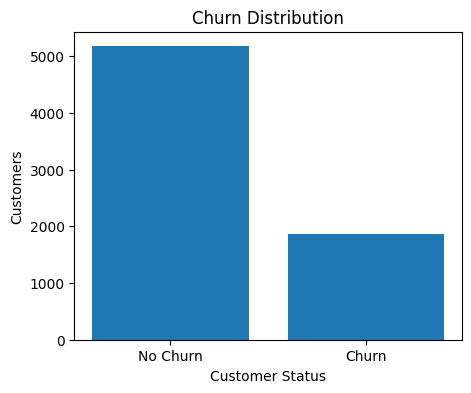

In [ ]:
print("Churn distribution:")
print(df["Churn"].value_counts().rename({0: "No Churn", 1: "Churn"}))

counts = df["Churn"].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(["No Churn", "Churn"], counts.values)
plt.title("Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Customers")
plt.show()

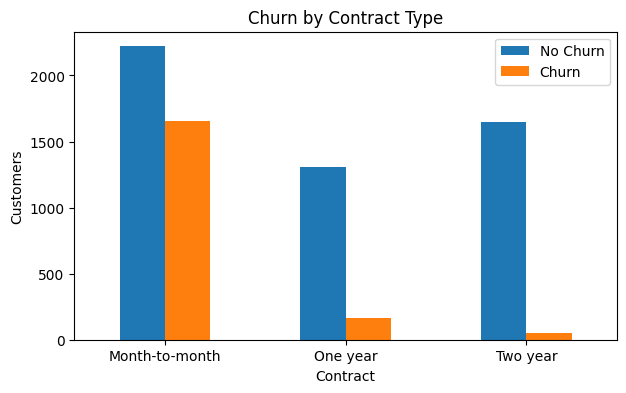

In [ ]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_churn.columns = ["No Churn", "Churn"]
contract_churn.plot(kind="bar", figsize=(7,4))
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

<Figure size 700x400 with 0 Axes>

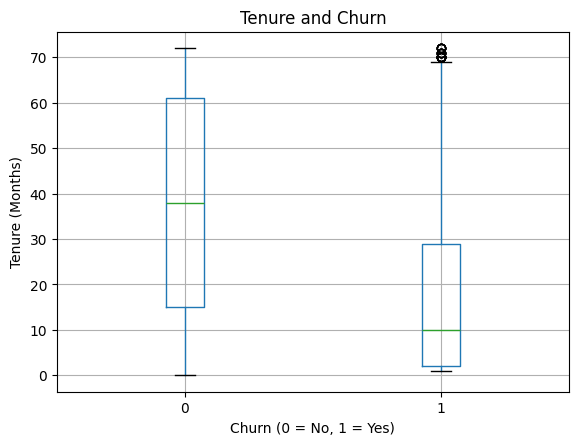

In [ ]:
plt.figure(figsize=(7,4))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure and Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")
plt.show()

The plots show that churn is not evenly distributed. Contract type and customer tenure also show noticeable differences between customers who churn and those who stay.

## 4. Feature Engineering and Encoding

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(exclude=["object"]).columns

print("Numerical features:", list(numeric_features))
print("\nCategorical features:", list(categorical_features))

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Training and Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5634
Testing rows: 1409


In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


## 6. Model Evaluation

In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040
1,Random Forest,0.7828,0.6181,0.4759,0.5378


In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name)
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
[[926 109]
 [165 209]]

Random Forest
[[925 110]
 [196 178]]



Logistic Regression gives higher Accuracy, Precision, Recall and F1-Score on the test set, so it is selected as the final model for this assignment.

## 7. Application / Prediction

In [ ]:
# Example customer data
sample_customer = X.iloc[[0]].copy()

print("Sample customer:")
display(sample_customer)

prediction = logistic_model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")

Sample customer:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


Prediction: Churn
